In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
from sklearn.model_selection import train_test_split

In [5]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.Collecting scikit-learn
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 409.0 kB/s eta 0:00:22
   -- ------------------------------------- 0.5/9.3 MB 409.0 kB/s eta 0:00:22
   --- ------------------------------------ 0.8/9.3 MB 479.2 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.3 MB 479.2 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.3 MB 479.2 kB/s eta 0:00:18
   ---- ----------------------------------- 1.0/9.3 MB 498.4 kB/s eta 0:00:17
   ----- ---------------------------------- 1.3/9.3 MB 554.5 kB/s eta 0:00:15
   ------ ----------

In [32]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [ ]:
%pip install XGBoost
%pip install CatBoost

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement xgboost (from versions: none)
ERROR: No matching distribution found for xgboost


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement catboost (from versions: none)
ERROR: No matching distribution found for catboost


In [10]:
import platform
print(platform.architecture())

('64bit', 'WindowsPE')


In [11]:
%pip install --upgrade pip
%pip install xgboost catboost



   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.0 MB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------- ----------------- 1.0/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.1 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2
Note: you may need to restart the kernel to use updated packages.Collecting xgboost
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 

In [14]:
df.drop(columns=['math_score'],axis=1)

NameError: name 'df' is not defined

In [15]:
df=pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
X=df.drop(columns=['math_score'],axis=1)

In [17]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [19]:
print('categorical features of gender: ',end=' ')
print(df['gender'].unique())

print('categorical feature of race_ethnicity: ',end=' ')
print(df['race_ethnicity'].unique())

print('categorical feature of parental_level_of_education: ',end=' ')
print(df['parental_level_of_education'].unique())

print('categorical feature of lunch: ',end=' ')
print(df['lunch'].unique())

print('categorical feature of test_prepration_course: ',end=' ')
print(df['test_preparation_course'].unique())

categorical features of gender:  ['female' 'male']
categorical feature of race_ethnicity:  ['group B' 'group C' 'group A' 'group D' 'group E']
categorical feature of parental_level_of_education:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categorical feature of lunch:  ['standard' 'free/reduced']
categorical feature of test_prepration_course:  ['none' 'completed']


In [21]:
y=df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [25]:
num_features=X.select_dtypes(exclude="object").columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder()

preproceaaor=ColumnTransformer(
    [('Standard_Scaler',num_transformer,num_features),
     ('OneHotEncoder',cat_transformer,cat_features)]
)

In [23]:
num_features

Index(['reading_score', 'writing_score'], dtype='object')

In [24]:
X.dtypes

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
reading_score                   int64
writing_score                   int64
dtype: object

In [26]:
X=preproceaaor.fit_transform(X)


In [28]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [36]:
def evaluate_model(true,predicted):
    mse=mean_squared_error(true,predicted)
    r2=r2_score(true,predicted)
    mae=mean_absolute_error(true,predicted)
    rmse=np.sqrt(mse)
    return mae,rmse,r2


In [37]:
models={
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "Random_Forest_Regressor":RandomForestRegressor(),
    "SVR":SVR(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    }




# Ensure these lists exist before starting the loop
model_list = []
r2_list = []

# Loop through name and model directly
for name, model in models.items():
    # 1. Train model
    model.fit(X_train, y_train)

    # 2. Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 3. Evaluate using your custom function
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    # 4. Store results
    model_list.append(name)
    r2_list.append(model_test_r2)
    
    # 5. Print Results
    print(f"Model: {name}")
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('-' * 35)
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('=' * 35)
    print('\n')


Model: LinearRegression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Model: Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


Model: Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
-----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Model: DecisionTreeRegressor
Model performance for Training set
- Root Mean Squared Error: 0.2795
- Mean Absolute Error: 0.0187
- R2 Score: 

In [38]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
1,Ridge,0.880593
0,LinearRegression,0.880433
7,CatBoostRegressor,0.851632
4,Random_Forest_Regressor,0.851367
2,Lasso,0.825320
6,XGBRegressor,0.821220
3,DecisionTreeRegressor,0.748539
5,SVR,0.728600


In [39]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


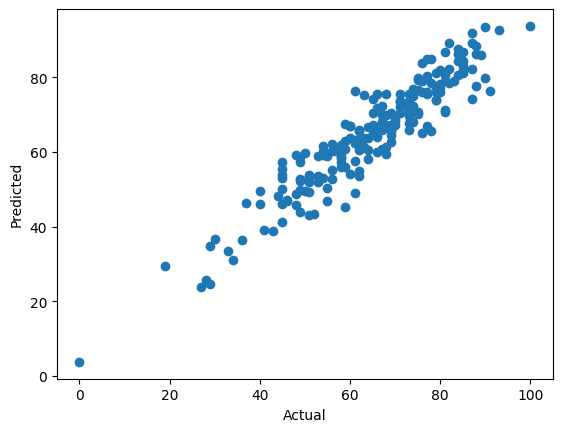

In [40]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

In [41]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
